In [23]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
from scipy.ndimage import gaussian_filter1d
import xarray as xr

In [3]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.4.2/'

In [4]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [5]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [6]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [7]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [8]:
# Find distance between two points
def Find_Distance(y1, y2, x1, x2):
    Start_Lat = y1 * numpy.pi / 180
    End_Lat = y2 * numpy.pi / 180
    Start_Lon = x1 * numpy.pi / 180
    End_Lon = x2 * numpy.pi / 180
    Lat_Diff = End_Lat - Start_Lat
    Lon_Diff = End_Lon - Start_Lon
    Earth_Rad = 6378
    Distance = 2 * Earth_Rad * numpy.sqrt((numpy.sin(Lat_Diff/2))**2 + \
    numpy.cos(Start_Lat) * numpy.cos(End_Lat) * (numpy.sin(Lon_Diff/2))**2)
    return (Distance)

In [9]:
# Find a specific storm within the dataframe
def Find_Storm(DF, Code):
    DF_Storm = DF[DF["Code"] == Code].reset_index(drop=True)
    return (DF_Storm)

In [10]:
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [19]:
# Calculate storm translation velocity
def Find_Velocity(DF_Storm):
    Lon_Diff = numpy.zeros(len(DF_Storm))
    Lat_Diff = numpy.zeros(len(DF_Storm))
    for i in range(len(DF_Storm)):
        if i < len(DF_Storm)-1:
            Lon_Diff[i] = DF_Storm["Lon"][i+1] - DF_Storm["Lon"][i]
            Lat_Diff[i] = DF_Storm["Lat"][i+1] - DF_Storm["Lat"][i]
        else:
            Lon_Diff[i], Lat_Diff[i] = numpy.nan, numpy.nan
    DF_Storm["u"] = Lon_Diff / 6
    DF_Storm["v"] = Lat_Diff / 6
    return (DF_Storm)

In [20]:
DF_Storm = Find_Storm(RCP45_Data, "TC200705")
Find_Velocity(DF_Storm)

,Code,Name,Lon,Lat,SLP(hPa),Winds(m/s),Dist(m),Angle,B,VLT,VUT,Time(Z),Storm Phase,u,v
0,TC200705,Demi,-44.40,35.31,1003.87,19.8,21.96,0.93,14.74,27.67,-45.11,2007-10-10 12:00:00,Tropical,0.000000,0.033333
1,TC200705,Demi,-44.40,35.51,1002.84,20.2,21.96,0.93,12.93,22.51,-48.16,2007-10-10 18:00:00,Tropical,0.001667,0.033333
2,TC200705,Demi,-44.39,35.71,1001.81,20.6,21.96,0.92,9.36,26.71,-45.35,2007-10-11 00:00:00,Tropical,0.000000,0.033333
3,TC200705,Demi,-44.39,35.91,1000.78,21.0,21.96,0.92,7.39,30.72,-32.51,2007-10-11 06:00:00,Tropical,0.060000,-0.111667
4,TC200705,Demi,-44.03,35.24,1001.63,18.4,80.96,156.03,4.53,37.46,-23.70,2007-10-11 12:00:00,Tropical,0.198333,-0.066667
5,TC200705,Demi,-42.84,34.84,1002.50,18.1,117.22,112.04,4.65,33.79,-20.72,2007-10-11 18:00:00,Tropical,0.200000,-0.065000
6,TC200705,Demi,-41.64,34.45,1003.36,17.7,117.71,111.95,7.99,32.50,-16.00,2007-10-12 00:00:00,Tropical,0.205000,0.005000
7,TC200705,Demi,-40.41,34.48,1003.23,18.3,112.86,88.02,11.00,39.78,-13.00,2007-10-12 06:00:00,Tropical,0.195000,0.023333
8,TC200705,Demi,-39.24,34.62,1004.00,22.1,108.90,81.77,7.68,44.53,-9.78,2007-10-12 12:00:00,Tropical,0.078333,-0.011667
9,TC200705,Demi,-38.77,34.55,1002.86,24.7,43.74,100.67,7.93,44.13,-1.09,2007-10-12 18:00:00,Tropical,-0.065000,-0.203333


In [21]:
# Create new DF with translation velocity info
def Velocity_DF(DF, Codes):
    for i in range(len(Codes)):
        DF_Storm = Find_Storm(DF, Codes["New Code"][i])
        DF_Storm = Find_Velocity(DF_Storm)
        if i == 0:
            DF_Velocity = DF_Storm.copy()
        else:
            DF_Velocity = pandas.concat([DF_Velocity, DF_Storm])
    DF_Velocity = DF_Velocity.reset_index(drop=True)
    return (DF_Velocity)

In [22]:
# Apply function
Control_Velo = Velocity_DF(Control_Data, Control_Codes)
RCP45_Velo = Velocity_DF(RCP45_Data, RCP45_Codes)
RCP85_Velo = Velocity_DF(RCP85_Data, RCP85_Codes)

In [68]:
# Calculate mean zonal and meridional velocity within each latitude range
def Lat_Range_DF(DF, Scenario, Lat_Min, Lat_Max, Bin_Width, Smooth_Param):
# Create latitude bins
    Lat_Bins = Create_Bins(Lat_Min, Lat_Max, Bin_Width)
    DF = DF[(DF["Lat"] >= Lat_Min) & (DF["Lat"] <= Lat_Max)].reset_index(drop=True)
    DF["Lat Bin"] = pandas.cut(DF["Lat"], bins=Lat_Bins)
    DF["Lat Mid"] = DF["Lat Bin"].apply(lambda x: x.mid)
# Group by latitude
    Groups = DF.groupby(["Lat Mid"], observed=False).agg(u_Mean=("u", "mean"), v_Mean=("v", "mean"), Count=("u", "count"))
    Groups = Groups.reset_index()
# Apply smoothing
    Groups["u Smooth"] = gaussian_filter1d(Groups["u_Mean"], sigma=Smooth_Param)
    Groups["v Smooth"] = gaussian_filter1d(Groups["v_Mean"], sigma=Smooth_Param)
# Rename columns
    Groups = Groups.rename(columns={"u Smooth": str(Scenario+" u"), "v Smooth": str(Scenario+" v"), "Count": str(Scenario+" Count")})
    Groups = Groups.drop(columns=["u_Mean", "v_Mean"])
    return (Groups)

In [126]:
# Apply function and combine into one dataframe
Control_Groups = Lat_Range_DF(Control_Velo, "Control", 8.75, 58.75, 2.5, 1.8)
RCP45_Groups = Lat_Range_DF(RCP45_Velo, "RCP4.5", 8.75, 58.75, 2.5, 1.8)
RCP85_Groups = Lat_Range_DF(RCP85_Velo, "RCP8.5", 8.75, 58.75, 2.5, 1.8)
Velo_DF = Control_Groups.merge(RCP45_Groups, on="Lat Mid", how="outer").merge(RCP85_Groups, on="Lat Mid", how="outer")
Velo_DF

,Lat Mid,Control Count,Control u,Control v,RCP4.5 Count,RCP4.5 u,RCP4.5 v,RCP8.5 Count,RCP8.5 u,RCP8.5 v
0,10.0,214,-0.169746,0.056283,118,-0.169091,0.072148,65,-0.154058,0.069492
1,12.5,658,-0.168350,0.058239,320,-0.171097,0.071134,207,-0.156719,0.068166
2,15.0,906,-0.161142,0.062784,547,-0.169494,0.071804,535,-0.155025,0.067898
3,17.5,797,-0.143564,0.069697,494,-0.157482,0.076056,497,-0.141229,0.071003
4,20.0,744,-0.114637,0.077372,447,-0.131908,0.082833,375,-0.112597,0.077181
5,22.5,782,-0.077178,0.084239,445,-0.094792,0.089419,400,-0.072081,0.083873
6,25.0,987,-0.035714,0.090134,454,-0.051268,0.093724,477,-0.025396,0.088913
7,27.5,905,0.006066,0.095908,527,-0.006308,0.095512,533,0.022255,0.092093
8,30.0,974,0.047126,0.102410,650,0.037595,0.096539,661,0.068110,0.094727
9,32.5,909,0.089102,0.110482,763,0.081096,0.099809,699,0.111958,0.098795


In [127]:
# Plot zonal velocity at each latitude
def Plot_Lon_Velo(Axis, Velo_DF):
    Axis.plot(Velo_DF["Control u"], Velo_DF["Lat Mid"], c='limegreen', linewidth=1.8, label='Control')
    Axis.plot(Velo_DF["RCP4.5 u"], Velo_DF["Lat Mid"], c='darkorange', linewidth=1.8, label='RCP4.5')
    Axis.plot(Velo_DF["RCP8.5 u"], Velo_DF["Lat Mid"], c='red', linewidth=1.8, label='RCP8.5')
# Formatting
    pyplot.xlim(-0.3,0.5)
    pyplot.xticks(Create_Bins(-0.3,0.5,0.1))
    pyplot.ylim(10,62.5)
    pyplot.yticks(Create_Bins(10,57.5,2.5))
    pyplot.xlabel("Zonal Velocity (°/hr)", fontsize=16)
    pyplot.ylabel("Latitude", fontsize=16)
    pyplot.title("Average Zonal Velocity VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')

In [128]:
# Plot meridional velocity at each latitude
def Plot_Lat_Velo(Axis, Velo_DF):
    Axis.plot(Velo_DF["Control v"], Velo_DF["Lat Mid"], c='limegreen', linewidth=1.8, label='Control')
    Axis.plot(Velo_DF["RCP4.5 v"], Velo_DF["Lat Mid"], c='darkorange', linewidth=1.8, label='RCP4.5')
    Axis.plot(Velo_DF["RCP8.5 v"], Velo_DF["Lat Mid"], c='red', linewidth=1.8, label='RCP8.5')
# Formatting
    pyplot.xlim(0.02,0.18)
    pyplot.xticks(Create_Bins(0.02,0.24,0.02))
    pyplot.ylim(10,62.5)
    pyplot.yticks(Create_Bins(10,57.5,2.5))
    pyplot.xlabel("Meridional Velocity (°/hr)", fontsize=16)
    pyplot.title("Average Meridional Velocity VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')
# Legend
    pyplot.legend(loc=2, fontsize=15)

In [129]:
# Plot vectors of translation motion for each latitude
def Plot_Vectors(Axis, Velo_DF):
    Vector_Plotting(Velo_DF, "Control u", "Control v", 'limegreen', "Control")
    Vector_Plotting(Velo_DF, "RCP4.5 u", "RCP4.5 v", 'darkorange', "RCP4.5")
    Vector_Plotting(Velo_DF, "RCP8.5 u", "RCP8.5 v", 'red', "RCP8.5")
    pyplot.xlim(-0.03,0.03)
    pyplot.ylim(10,62.5)
    pyplot.yticks(Create_Bins(10,57.5,2.5))
    pyplot.title("Average Motion Vector VS Latitude", fontsize=20)
    Axis.grid(linewidth=0.5, color='silver', linestyle='-')

In [130]:
# Plot vectors of translation motion
def Vector_Plotting(Velo_DF, Lon_Velo, Lat_Velo, Colour, Label):
    Zeros = numpy.zeros(len(Velo_DF["Lat Mid"]))
    pyplot.quiver(Zeros, Velo_DF["Lat Mid"], Velo_DF[Lon_Velo], Velo_DF[Lat_Velo], color=Colour, label=Label, \
    scale=1, width=0.005)

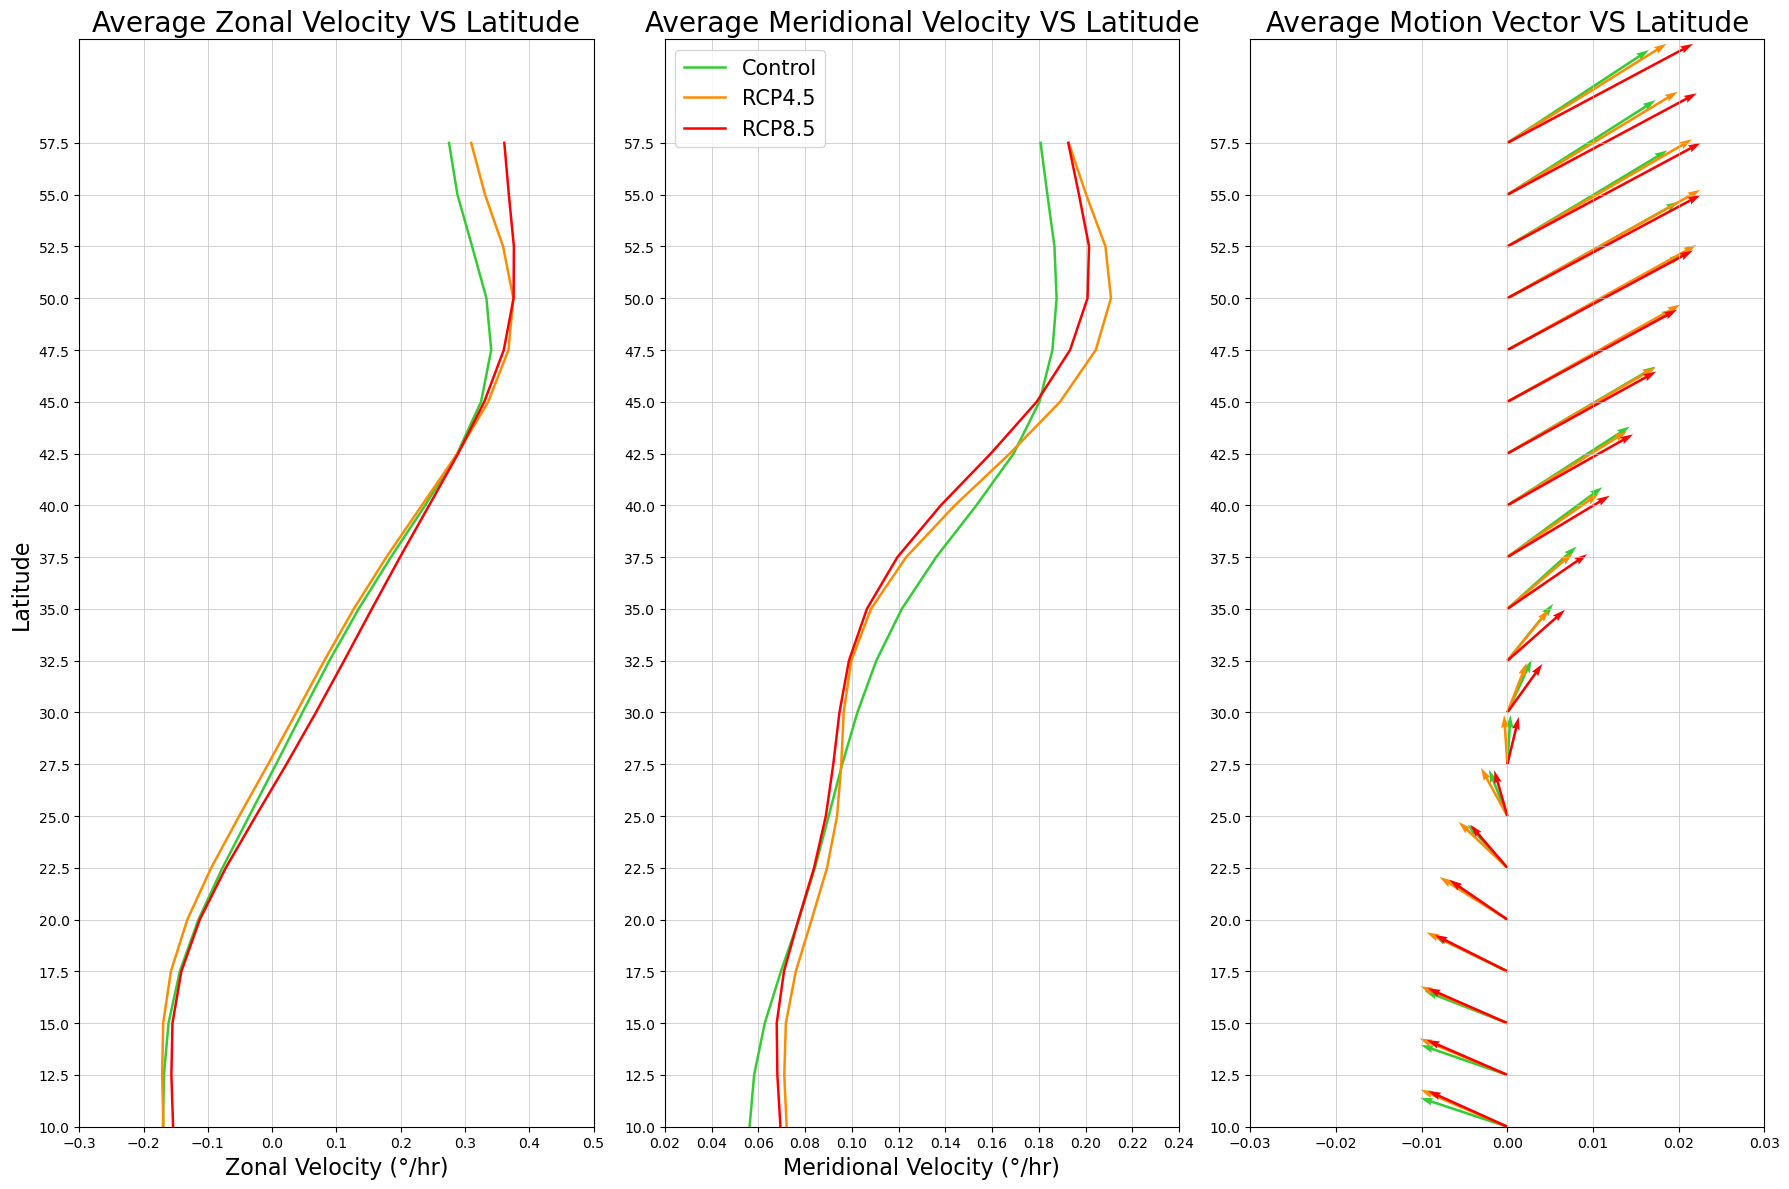

In [131]:
# Create figure
Fig = pyplot.figure(figsize=(18,12))
#
# Plot zonal velocity
Ax1 = Fig.add_subplot(1,3,1)
Plot_Lon_Velo(Ax1, Velo_DF)
#
# Plot meridional velocity
Ax2 = Fig.add_subplot(1,3,2)
Plot_Lat_Velo(Ax2, Velo_DF)
#
# Plot vectors
Ax3 = Fig.add_subplot(1,3,3)
Plot_Vectors(Ax3, Velo_DF)
#
# Save figure
pyplot.tight_layout()
Fig.savefig(Output_Diri+'Motion_Vectors.png', bbox_inches='tight')